# 초급 프로젝트 미션

## 프로젝트 개요

첫번째 프로젝트에 오신 스프린터 여러분들을 환영합니다!

- 지금까지 학습하신 커리큘럼 초반부의 내용들을 토대로, **이미지 인식 기술을 헬스케어 분야에 접목해보는** 프로젝트를 진행해봅시다.
- 여러분들을 헬스케어 스타트업 : 헬스잇(Health Eat) 의 AI 엔지니어링 팀이라고 가정해 볼게요.
    - 헬스잇의 AI 엔지니어링 팀은 유저가 본인의 모바일 애플리케이션으로 자신이 복용중인 약 사진을 찍었을 때, 이미지 인식을 통해 해당 약에 대한 정보를 확인할 수 있는 모델을 만들어야하는 미션을 부여받았습니다.
    - 기업에서는 이를 통해 유저의 건강 상태 및 함께 복용하면 안되는 약 등 헬스케어 정보를 유저들에게 제공함으로써 비즈니스적인 가치를 만들어낼 수 있겠죠.
- 사진 속에 있는 최대 4개의 알약의 이름(클래스)과 위치(바운딩 박스)를 검출하는 모델을 구현하고, 성능을 지속적으로 개선해나가는 것이 프로젝트의 목표입니다.
    
        
- 모델 성능 검증은 코드잇 스프린트에서 별도로 세팅해둔 Kaggle에서 진행됩니다.
    - Submission 가이드라인에 따라 Output을 제출하고 Leaderbord를 통해 모델 성능을 대략적으로 확인해보세요.
    - 순위는 중요하지 않아요. 자신이 속한 팀의 점수가 지속적으로 향상되는지를 확인해보고, 향상되었다면 왜 그랬는지 트래킹하기 위한 수단으로 활용해 봅시다.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import unicodedata  # 0번 섹션에 추가 필요

# 📌 경로 설정 (제공해주신 경로 반영)
def normalize_path(path):
    # 1. unicodedata.normalize('NFC', path): 경로 문자열을 NFC 방식으로 통일
    # 2. .strip(): 앞뒤에 붙은 불필요한 공백 제거
    return unicodedata.normalize('NFC', path).strip()

In [ ]:
############################################################
# 0. 라이브러리 임포트 & 경로 설정
############################################################
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import unicodedata  # 0번 섹션에 추가 필요
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 경로 설정
def normalize_path(path):
    # 1. unicodedata.normalize('NFC', path): 경로 문자열을 NFC 방식으로 통일
    # 2. .strip(): 앞뒤에 붙은 불필요한 공백 제거
    return unicodedata.normalize('NFC', path).strip()

# 경로는 환경에 맞게 수정
# train_images, test_images
extract_path = normalize_path("/content/drive/MyDrive/data/초급_프로젝트/dataset/") # 압축을 풀 폴더

TRAIN_JSON_PATH = os.path.join(extract_path, "merged_annotations_train_final.json")
TEST_JSON_PATH = os.path.join(extract_path, "merged_annotations_test_final.json")
TRAIN_IMG_DIR = os.path.join(extract_path, "train_images")
TEST_IMG_DIR  = os.path.join(extract_path, "test_images")


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



plt.rc('font', family='Malgun Gothic')  # 한글 폰트 설정
plt.rc('axes', unicode_minus=False)     # 마이너스 기호 깨짐 방지


In [ ]:
############################################################
# 1. 병합된 JSON 파일을 읽어서 DataFrame으로 만들기
############################################################

def build_df_from_merged_json(json_path, img_dir):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # 1) 이미지 정보 매핑 (id -> file_name)
    id_to_fname = {img["id"]: img["file_name"] for img in data["images"]}

    records = []
    # 2) 어노테이션 순회
    for ann in data["annotations"]:
        img_id_coco = ann["image_id"]
        file_name = id_to_fname.get(img_id_coco)
        
        if file_name is None: continue
        
        img_path = os.path.join(img_dir, file_name)
        
        # 실제 이미지 파일이 있는지 확인 (선택 사항이지만 안전함)
        if not os.path.exists(img_path):
            continue

        x, y, w, h = ann["bbox"]
        
        records.append({
            "image_path": img_path,
            "image_id": os.path.splitext(file_name)[0], # 파일명을 ID로 사용
            "category_id": int(ann["category_id"]),
            "bbox_x": float(x),
            "bbox_y": float(y),
            "bbox_w": float(w),
            "bbox_h": float(h),
        })

    return pd.DataFrame(records)

# 실행
df = build_df_from_merged_json(TRAIN_JSON_PATH, TRAIN_IMG_DIR)
print(f"✅ 학습 데이터 로드 완료: {len(df)} 개의 객체 탐지됨")

✅ 학습 데이터 로드 완료: 4526 개의 객체 탐지됨


In [ ]:
############################################################
# 2. category_id 매핑 (겉으로는 안 바꾸고, 모델 내부에서만 사용)
############################################################

# 원본 category_id 집합
unique_cats = sorted(df["category_id"].unique())
print("고유 category_id 개수:", len(unique_cats))

# 내부용: 모델에 넣을 label (1 ~ num_classes-1), 0은 background
orig2model = {cid: i + 1 for i, cid in enumerate(unique_cats)}   # 원본 → 모델용
model2orig = {v: k for k, v in orig2model.items()}               # 모델용 → 원본

num_classes = len(unique_cats) + 1  # background 포함
print("num_classes (background 포함):", num_classes)

고유 category_id 개수: 73
num_classes (background 포함): 74


In [ ]:
# 파일/폴더 존재 여부 체크
paths_to_check = {
    "TRAIN JSON": TRAIN_JSON_PATH,
    "TEST JSON" : TEST_JSON_PATH,
    "TRAIN IMG DIR": TRAIN_IMG_DIR,
    "TEST IMG DIR" : TEST_IMG_DIR,
}

for name, path in paths_to_check.items():
    exists = os.path.exists(path)
    status = "존재" if exists else "없음"
    print(f"{status} | {name}: {path}")

존재 | TRAIN JSON: ./dataset/merged_annotations_train_final.json
존재 | TEST JSON: ./dataset/merged_annotations_test_final.json
존재 | TRAIN IMG DIR: ./dataset/train_images
존재 | TEST IMG DIR: ./dataset/test_images


In [ ]:
# 이미지 파일 개수 확인
IMG_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp')

def count_images(directory):
    """디렉토리 내 이미지 파일 수를 반환"""
    if not os.path.exists(directory):
        return 0
    return sum(
        1 for f in os.listdir(directory)
        if f.lower().endswith(IMG_EXTENSIONS)
    )

n_train = count_images(TRAIN_IMG_DIR)
n_test  = count_images(TEST_IMG_DIR)

print(f"Train 이미지 수 : {n_train:,}")
print(f"Test  이미지 수 : {n_test:,}")
print(f"합계            : {n_train + n_test:,}")

Train 이미지 수 : 1,489
Test  이미지 수 : 843
합계            : 2,332


### 1. 클래스별 데이터 분포 확인 (불균형 체크)
73개의 클래스가 얼마나 균일하게 퍼져 있는지 확인해야 합니다. 특정 약물 데이터가 너무 적으면 모델이 그 약을 아예 인식하지 못할 수 있습니다.

In [ ]:
# 샘플 데이터 구조 출력
with open(TRAIN_JSON_PATH, 'r', encoding='utf-8') as f:
    train_json = json.load(f)

with open(TEST_JSON_PATH, 'r', encoding='utf-8') as f:
    test_json = json.load(f)

# JSON 최상위 키 확인
print("Train JSON 최상위 키:", list(train_json.keys()))
print("Test  JSON 최상위 키:", list(test_json.keys()))

Train JSON 최상위 키: ['images', 'annotations', 'categories']
Test  JSON 최상위 키: ['images', 'annotations', 'categories']


In [ ]:
for split_name, data in [("Train", train_json), ("Test", test_json)]:
    print(f"[{split_name}]")
    print(f"  이미지 수          : {len(data['images'])}")
    print(f"  어노테이션 수      : {len(data['annotations'])}")
    print(f"  클래스 수 : {len(data['categories'])}")
    print()

[Train]
  이미지 수          : 1489
  어노테이션 수      : 4526
  클래스 수 : 73

[Test]
  이미지 수          : 843
  어노테이션 수      : 1129
  클래스 수 : 73



In [ ]:
print("=== images 샘플 ===")
print(json.dumps(train_json['images'][0], ensure_ascii=False, indent=2))

print("\n=== annotations 샘플 ===")
print(json.dumps(train_json['annotations'][0], ensure_ascii=False, indent=2))

print("\n=== categories 샘플 (앞 5개) ===")
for cat in train_json['categories'][:5]:
    print(cat)

=== images 샘플 ===
{
  "file_name": "K-001900-016551-024850-027926_0_2_0_2_90_000_200.png",
  "width": 976,
  "height": 1280,
  "imgfile": "K-001900-016551-024850-027926_0_2_0_2_90_000_200.png",
  "drug_N": "K-001900",
  "drug_S": "정상알약",
  "back_color": "연회색 배경",
  "drug_dir": "앞면",
  "light_color": "주백색",
  "camera_la": 90,
  "camera_lo": 0,
  "size": 200,
  "dl_idx": "1899",
  "dl_mapping_code": "K-001900",
  "dl_name": "보령부스파정 5mg",
  "dl_name_en": "Buspar Tab. 5mg Boryung",
  "img_key": "http://connectdi.com/design/img/drug/1Mxwka5v0lL.jpg",
  "dl_material": "부스피론염산염",
  "dl_material_en": "Buspirone Hydrochloride",
  "dl_custom_shape": "정제, 저작정",
  "dl_company": "보령제약(주)",
  "dl_company_en": "Boryung",
  "di_company_mf": "",
  "di_company_mf_en": "",
  "item_seq": 198700706,
  "di_item_permit_date": "19870323",
  "di_class_no": "[01170]정신신경용제",
  "di_etc_otc_code": "전문의약품",
  "di_edi_code": "641901280,A09302381",
  "chart": "이약은 양면볼록한 장방형의 흰색정제이다",
  "drug_shape": "장방형",
  "thick":

In [ ]:
from collections import Counter
# category_id → 이름 매핑
train_id2name = {cat['id']: cat['name'] for cat in train_json['categories']}

# 클래스별 어노테이션 수 집계
cat_counter = Counter(annot['category_id'] for annot in train_json['annotations'])

train_df_class = pd.DataFrame([
    {'category_id': cid, 'name': train_id2name.get(cid, '?'), 'count': cnt}
    for cid, cnt in cat_counter.most_common()
])

print(f"총 클래스 수: {len(train_df_class)}")
print(f"전체 어노테이션 수: {train_df_class['count'].sum():,}")
print(f"\n최다 클래스: {train_df_class.iloc[0]['name']} ({train_df_class.iloc[0]['count']}개)")
print(f"최소 클래스: {train_df_class.iloc[-1]['name']} ({train_df_class.iloc[-1]['count']}개)")
print(f"최대/최소 비율: {train_df_class['count'].max() / train_df_class['count'].min():.1f}x")
print(f"\n상위 10개 클래스:")
print(train_df_class.head(10).to_string(index=False))

총 클래스 수: 73
전체 어노테이션 수: 4,526

최다 클래스: 기넥신에프정(은행엽엑스)(수출용) (514개)
최소 클래스: 브린텔릭스정 20mg (7개)
최대/최소 비율: 73.4x

상위 10개 클래스:
 category_id               name  count
        3482 기넥신에프정(은행엽엑스)(수출용)    514
        3350        일양하이트린정 2mg    240
        1899         보령부스파정 5mg    180
        2482        뮤테란캡슐 100mg    172
       16547        가바토파정 100mg    143
       16550      동아가바펜틴정 800mg    139
       35205       아토젯정 10/40mg    113
       29666           리바로정 4mg    111
       16231          리피토정 20mg    109
       36636       로수젯정10/5밀리그램    108


In [ ]:
from collections import Counter
import pandas as pd

# category_id → 이름 매핑
test_id2name = {cat['id']: cat['name'] for cat in test_json['categories']}

# 클래스별 어노테이션 수 집계
test_cat_counter = Counter(annot['category_id'] for annot in test_json['annotations'])

# DataFrame 생성
test_df_class = pd.DataFrame([
    {'category_id': cid, 'name': test_id2name.get(cid, '?'), 'count': cnt}
    for cid, cnt in test_cat_counter.most_common()
])

print(f"총 클래스 수: {len(test_df_class)}")
print(f"전체 어노테이션 수: {test_df_class['count'].sum():,}")
print(f"\n최다 클래스: {test_df_class.iloc[0]['name']} ({test_df_class.iloc[0]['count']}개)")
print(f"최소 클래스: {test_df_class.iloc[-1]['name']} ({test_df_class.iloc[-1]['count']}개)")
print(f"최대/최소 비율: {test_df_class['count'].max() / test_df_class['count'].min():.1f}x")
print(f"\n상위 10개 클래스:")
print(test_df_class.head(10).to_string(index=False))

총 클래스 수: 73
전체 어노테이션 수: 1,129

최다 클래스: 기넥신에프정(은행엽엑스)(수출용) (110개)
최소 클래스: 졸로푸트정 100mg (1개)
최대/최소 비율: 110.0x

상위 10개 클래스:
 category_id               name  count
        3482 기넥신에프정(은행엽엑스)(수출용)    110
        2482        뮤테란캡슐 100mg     53
        3350        일양하이트린정 2mg     52
        1899         보령부스파정 5mg     42
       19860          노바스크정 5mg     36
       16550      동아가바펜틴정 800mg     34
       16547        가바토파정 100mg     31
       16261         크레스토정 20mg     30
       27652       세비카정 10/40mg     29
       25468      아모잘탄정 5/100mg     29


In [ ]:
import numpy as np

In [ ]:
widths, heights = [], []

for img_info in train_json['images']:
    widths.append(img_info['width'])
    heights.append(img_info['height'])

print(f"Width  - min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Height - min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")

# 해상도 조합별 빈도 확인
resolution_counter = Counter(zip(widths, heights))
print(f"\n해상도 종류 수: {len(resolution_counter)}")
print("\n상위 5개 해상도:")
for (w, h), cnt in resolution_counter.most_common(5):
    print(f"  {w}x{h} : {cnt}장")

Width  - min: 976, max: 976, mean: 976
Height - min: 1280, max: 1280, mean: 1280

해상도 종류 수: 1

상위 5개 해상도:
  976x1280 : 1489장


In [ ]:
# 이미지당 객체 수 분포
img_annot_count = Counter(annot['image_id'] for annot in train_json['annotations'])
obj_counts = list(img_annot_count.values())

print("이미지당 알약 수 분포:")
for k, v in sorted(Counter(obj_counts).items()):
    print(f"  {k}개 알약: {v:5d}장")

print(f"\n평균 객체 수: {np.mean(obj_counts):.2f}")
print(f"최대 객체 수: {max(obj_counts)}")

이미지당 알약 수 분포:
  1개 알약:    64장
  2개 알약:   302장
  3개 알약:   634장
  4개 알약:   489장

평균 객체 수: 3.04
최대 객체 수: 4


In [ ]:
bbox_widths, bbox_heights, bbox_areas = [], [], []

for annot in train_json['annotations']:
    x, y, w, h = annot['bbox']
    bbox_widths.append(w)
    bbox_heights.append(h)
    bbox_areas.append(w * h)

print(f"BBox 너비 - min: {min(bbox_widths):.0f}, max: {max(bbox_widths):.0f}, mean: {np.mean(bbox_widths):.0f}")
print(f"BBox 높이 - min: {min(bbox_heights):.0f}, max: {max(bbox_heights):.0f}, mean: {np.mean(bbox_heights):.0f}")
print(f"BBox 면적 - min: {min(bbox_areas):.0f}, max: {max(bbox_areas):.0f}, mean: {np.mean(bbox_areas):.0f}")

# 이미지 대비 BBox 크기 비율
img_w, img_h = 976, 1280
print(f"\n이미지 대비 BBox 평균 비율:")
print(f"  너비: {np.mean(bbox_widths)/img_w*100:.1f}%")
print(f"  높이: {np.mean(bbox_heights)/img_h*100:.1f}%")

BBox 너비 - min: 125, max: 529, mean: 259
BBox 높이 - min: 123, max: 669, mean: 289
BBox 면적 - min: 18492, max: 272435, mean: 78884

이미지 대비 BBox 평균 비율:
  너비: 26.6%
  높이: 22.6%


In [ ]:
invalid_bboxes = []

for annot in train_json['annotations']:
    x, y, w, h = annot['bbox']
    # 너비/높이가 0 이하이거나 이미지 밖으로 나간 경우
    if w <= 0 or h <= 0 or x < 0 or y < 0 or x + w > 976 or y + h > 1280:
        invalid_bboxes.append(annot['id'])

print(f"비정상 BBox 수: {len(invalid_bboxes)}")

비정상 BBox 수: 2


In [ ]:
for annot in train_json['annotations']:
    x, y, w, h = annot['bbox']
    if w <= 0 or h <= 0 or x < 0 or y < 0 or x + w > 976 or y + h > 1280:
        print(f"annotation id : {annot['id']}")
        print(f"image_id      : {annot['image_id']}")
        print(f"bbox          : {annot['bbox']}")
        print(f"x+w={x+w:.1f} (max 976), y+h={y+h:.1f} (max 1280)")
        print()

annotation id : 903
image_id      : 239
bbox          : [6567, 625, 311, 315]
x+w=6878.0 (max 976), y+h=940.0 (max 1280)

annotation id : 1157
image_id      : 310
bbox          : [653, 8889, 217, 217]
x+w=870.0 (max 976), y+h=9106.0 (max 1280)



--- 알약 1개 샘플 ---


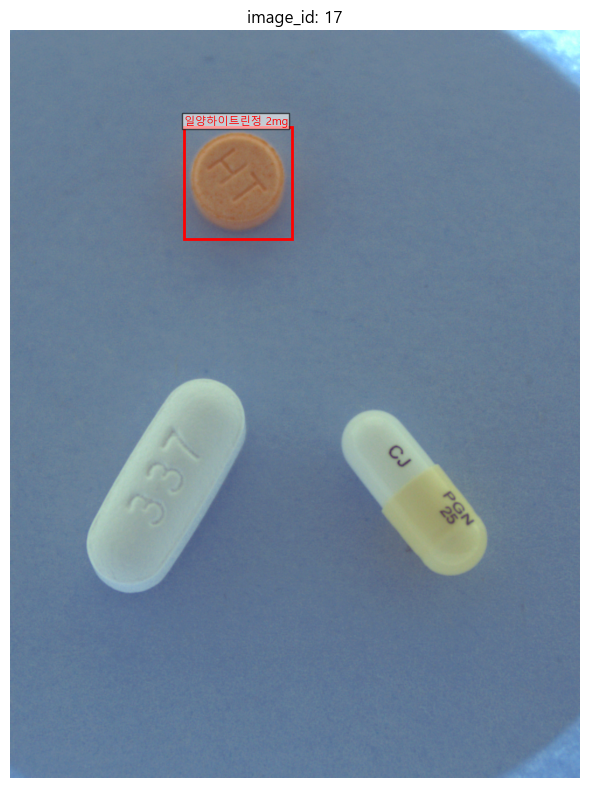

--- 알약 2개 샘플 ---


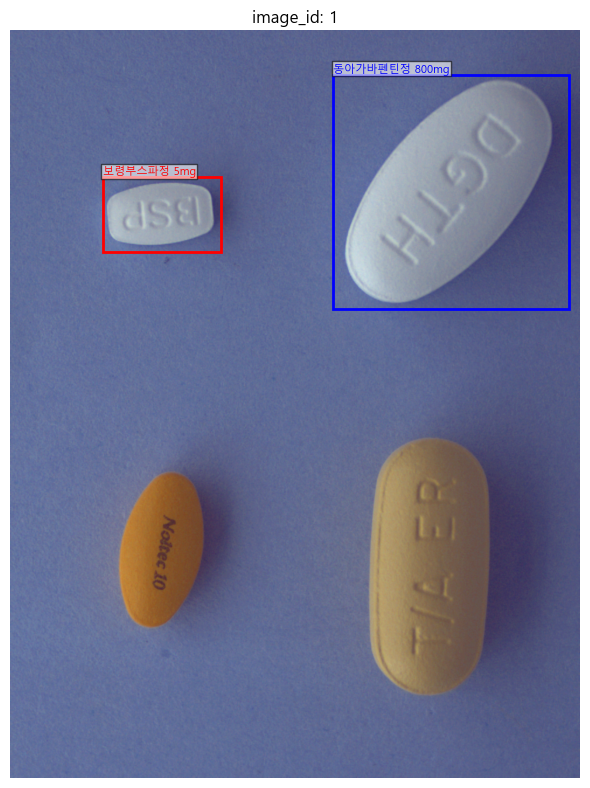

--- 알약 3개 샘플 ---


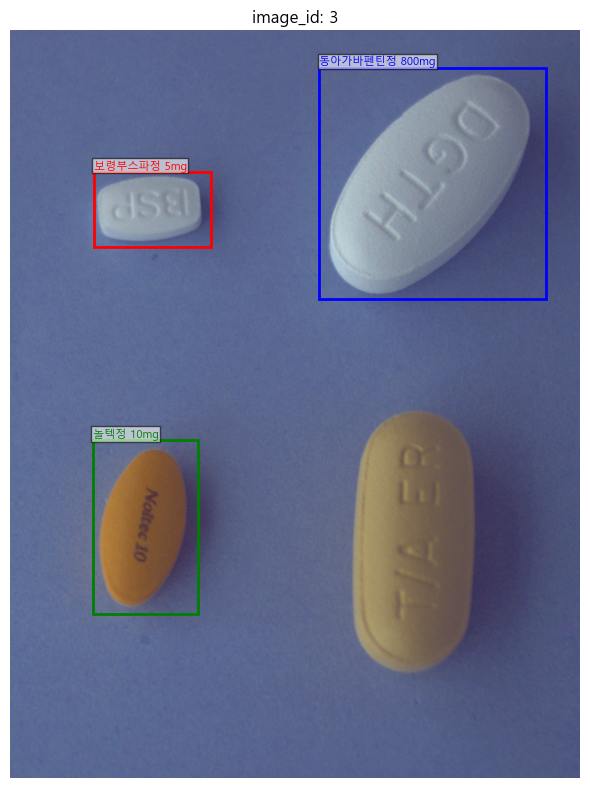

--- 알약 4개 샘플 ---


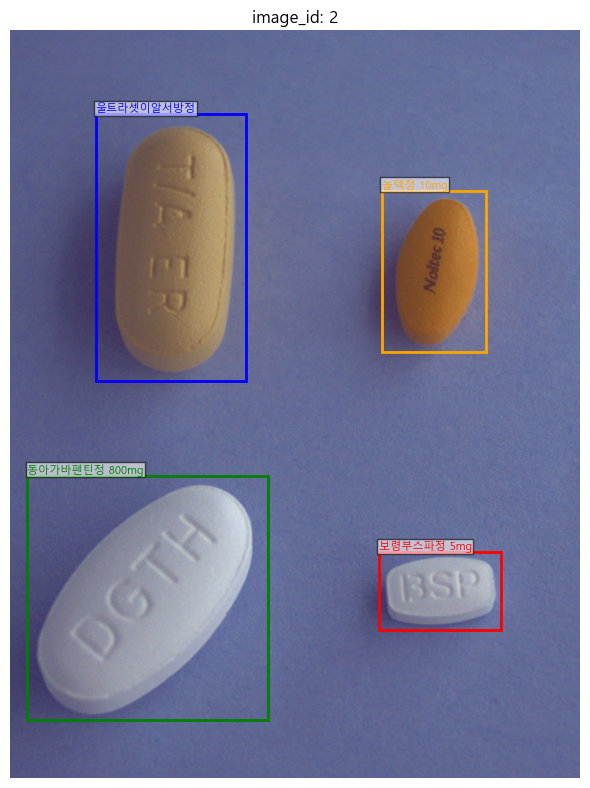

In [ ]:
from collections import defaultdict
import matplotlib.patches as patches

id2filename = {img['id']: img['file_name'] for img in train_json['images']}

img2annots = defaultdict(list)
for annot in train_json['annotations']:
    img2annots[annot['image_id']].append(annot)

def visualize_sample(image_id):
    fname = id2filename.get(image_id)
    img_path = os.path.join(TRAIN_IMG_DIR, os.path.basename(fname))
    img = Image.open(img_path).convert('RGB')

    fig, ax = plt.subplots(1, figsize=(6, 8))
    ax.imshow(img)

    colors = ['red', 'blue', 'green', 'orange']
    for i, annot in enumerate(img2annots[image_id]):
        x, y, w, h = annot['bbox']
        color = colors[i % len(colors)]
        rect = patches.Rectangle((x, y), w, h,
                                   linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        label = train_id2name.get(annot['category_id'], '?')
        ax.text(x, y - 5, label, color=color, fontsize=8,
                bbox=dict(facecolor='white', alpha=0.6, pad=1))

    ax.set_title(f"image_id: {image_id}")
    ax.axis('off')
    plt.tight_layout()
    plt.show()

# 알약 수별로 샘플 1장씩 시각화
for n_obj in [1, 2, 3, 4]:
    sample_id = [img_id for img_id, cnt in img_annot_count.items() if cnt == n_obj][0]
    print(f"--- 알약 {n_obj}개 샘플 ---")
    visualize_sample(sample_id)

In [ ]:
# 라벨링 안 된 알약이 얼마나 되는지 파악하기 위해
# 어노테이션 수 분포를 다시 한번 확인
print("어노테이션 기준 이미지당 알약 수:")
for k, v in sorted(Counter(obj_counts).items()):
    print(f"  라벨 {k}개: {v:5d}장 ({v/len(obj_counts)*100:.1f}%)")

어노테이션 기준 이미지당 알약 수:
  라벨 1개:    64장 (4.3%)
  라벨 2개:   302장 (20.3%)
  라벨 3개:   634장 (42.6%)
  라벨 4개:   489장 (32.8%)


In [ ]:
# category_id 재매핑 (불연속 id → 0부터 연속 정수)
original_ids = sorted([cat['id'] for cat in train_json['categories']])
id_remap = {old_id: new_id for new_id, old_id in enumerate(original_ids)}

# categories 업데이트
for cat in train_json['categories']:
    cat['id'] = id_remap[cat['id']]

# annotations 업데이트
for annot in train_json['annotations']:
    annot['category_id'] = id_remap[annot['category_id']]

# 확인
print(f"총 클래스 수: {len(id_remap)}")
print("\n재매핑 샘플 (앞 5개):")
for old, new in list(id_remap.items())[:5]:
    print(f"  {old:6d} → {new}")

총 클래스 수: 73

재매핑 샘플 (앞 5개):
    1899 → 0
    2482 → 1
    3350 → 2
    3482 → 3
    3543 → 4


In [ ]:
# 양방향 매핑 저장
new_id2name = {cat['id']: cat['name'] for cat in train_json['categories']}
new_id2old  = {new_id: old_id for old_id, new_id in id_remap.items()}
old_id2new  = id_remap  # 이미 만들어둔 것

print("새 id → 약 이름:")
for i in range(5):
    print(f"  {i} → {new_id2name[i]}")

print("\n새 id → 원래 id:")
for i in range(5):
    print(f"  {i} → {new_id2old[i]}")

새 id → 약 이름:
  0 → 보령부스파정 5mg
  1 → 뮤테란캡슐 100mg
  2 → 일양하이트린정 2mg
  3 → 기넥신에프정(은행엽엑스)(수출용)
  4 → 무코스타정(레바미피드)(비매품)

새 id → 원래 id:
  0 → 1899
  1 → 2482
  2 → 3350
  3 → 3482
  4 → 3543


In [ ]:
from PIL import Image, ImageOps
import os

def letterbox(image, target_size=640, fill_color=(114, 114, 114)):
    """
    비율을 유지하며 target_size x target_size 로 변환
    빈 공간은 fill_color 로 채움 (YOLO 기본값: 회색 114)
    반환값: 패딩된 이미지, (scale, pad_w, pad_h)
    """
    orig_w, orig_h = image.size
    scale = target_size / max(orig_w, orig_h)
    new_w = int(orig_w * scale)
    new_h = int(orig_h * scale)

    image = image.resize((new_w, new_h), Image.BILINEAR)

    # 좌우/상하 패딩 계산
    pad_w = (target_size - new_w) // 2
    pad_h = (target_size - new_h) // 2

    image = ImageOps.expand(image, (pad_w, pad_h, target_size - new_w - pad_w, target_size - new_h - pad_h), fill=fill_color)

    return image, (scale, pad_w, pad_h)

def transform_bbox(bbox, scale, pad_w, pad_h):
    """
    원본 BBox 좌표를 letterbox 변환에 맞게 조정
    bbox: [x, y, w, h] (COCO 포맷)
    """
    x, y, w, h = bbox
    x = x * scale + pad_w
    y = y * scale + pad_h
    w = w * scale
    h = h * scale
    return [x, y, w, h]

# 샘플 1장으로 확인
sample_img_info = train_json['images'][0]
sample_path = os.path.join(TRAIN_IMG_DIR, os.path.basename(sample_img_info['file_name']))

orig_img = Image.open(sample_path).convert('RGB')
resized_img, (scale, pad_w, pad_h) = letterbox(orig_img)

print(f"원본 크기  : {orig_img.size}")
print(f"변환 후 크기: {resized_img.size}")
print(f"scale={scale:.4f}, pad_w={pad_w}, pad_h={pad_h}")

원본 크기  : (976, 1280)
변환 후 크기: (512, 512)
scale=0.4000, pad_w=61, pad_h=0


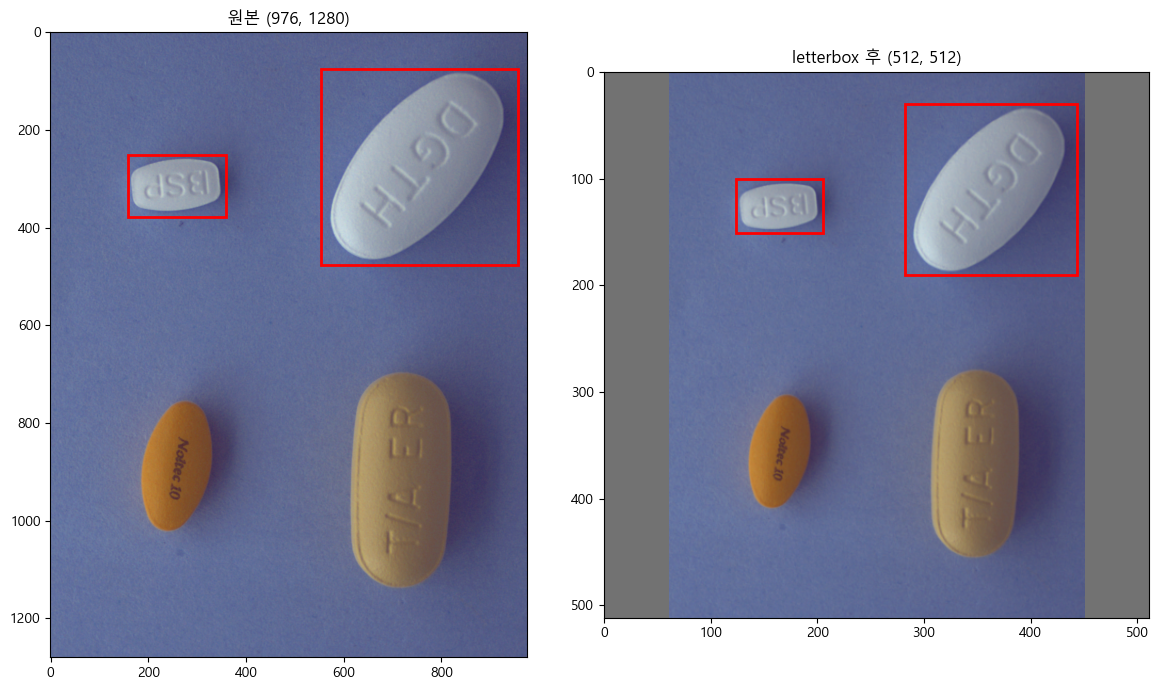

In [ ]:
import matplotlib.patches as patches

sample_annots = [a for a in train_json['annotations'] if a['image_id'] == sample_img_info['id']]

fig, axes = plt.subplots(1, 2, figsize=(12, 7))

# 원본
axes[0].imshow(orig_img)
axes[0].set_title(f"원본 {orig_img.size}")
for annot in sample_annots:
    x, y, w, h = annot['bbox']
    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
    axes[0].add_patch(rect)

# letterbox 변환 후
axes[1].imshow(resized_img)
axes[1].set_title(f"letterbox 후 {resized_img.size}")
for annot in sample_annots:
    x, y, w, h = transform_bbox(annot['bbox'], scale, pad_w, pad_h)
    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
    axes[1].add_patch(rect)

plt.tight_layout()
plt.show()

In [ ]:
import os

PROCESSED_TRAIN_IMG_DIR = os.path.join(extract_path, "processed_train_images")
os.makedirs(PROCESSED_TRAIN_IMG_DIR, exist_ok=True)

# 전체 이미지에 letterbox 적용 후 저장
scale_info = {}  # image_id → (scale, pad_w, pad_h) 저장

for img_info in train_json['images']:
    img_path = os.path.join(TRAIN_IMG_DIR, os.path.basename(img_info['file_name']))
    save_path = os.path.join(PROCESSED_TRAIN_IMG_DIR, os.path.basename(img_info['file_name']))

    img = Image.open(img_path).convert('RGB')
    resized, (scale, pad_w, pad_h) = letterbox(img)
    resized.save(save_path)

    scale_info[img_info['id']] = (scale, pad_w, pad_h)

print(f"저장 완료: {len(scale_info)}장 → {PROCESSED_TRAIN_IMG_DIR}")

저장 완료: 1489장 → ./dataset/processed_train_images


In [ ]:
import os
from PIL import Image

TEST_IMG_DIR = "./dataset/test_images"
PROCESSED_TEST_IMG_DIR = "./dataset/processed_test_images"

os.makedirs(PROCESSED_TEST_IMG_DIR, exist_ok=True)  # 디렉토리 생성

count = 0

for filename in os.listdir(TEST_IMG_DIR):
    if filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        file_path = os.path.join(TEST_IMG_DIR, filename)
        try:
            img = Image.open(file_path).convert("RGB")
            resized, (scale, pad_w, pad_h) = letterbox(img)  # letterbox 함수 확인 필요

            save_path = os.path.join(PROCESSED_TEST_IMG_DIR, filename)
            resized.save(save_path)
            count += 1
        except Exception as e:
            print(f"Error processing {filename}: {e}")

print(f"저장 완료: {count}장 → {PROCESSED_TEST_IMG_DIR}")

저장 완료: 843장 → ./dataset/processed_test_images


In [ ]:
import os

YOLO_BASE = "./dataset/yolo"

paths = [
    "images/train",
    "images/val",
    "labels/train",
    "labels/val"
]

for p in paths:
    os.makedirs(os.path.join(YOLO_BASE, p), exist_ok=True)

print("YOLO 폴더 구조 생성 완료")

YOLO 폴더 구조 생성 완료


In [ ]:
from PIL import Image
import os

YOLO_IMG_TRAIN = os.path.join(YOLO_BASE, "images/train")
YOLO_LBL_TRAIN = os.path.join(YOLO_BASE, "labels/train")

IMG_SIZE = 640  # letterbox 크기

for img_info in train_json['images']:
    img_id = img_info['id']
    file_name = os.path.basename(img_info['file_name'])

    src_img_path = os.path.join(PROCESSED_TRAIN_IMG_DIR, file_name)
    dst_img_path = os.path.join(YOLO_IMG_TRAIN, file_name)

    # 이미지 복사
    Image.open(src_img_path).save(dst_img_path)

    # 해당 이미지 annotation 가져오기
    annots = [a for a in train_json['annotations'] if a['image_id'] == img_id]

    scale, pad_w, pad_h = scale_info[img_id]

    label_path = os.path.join(YOLO_LBL_TRAIN, file_name.replace(".jpg", ".txt").replace(".png", ".txt"))

    with open(label_path, 'w') as f:
        for ann in annots:
            x, y, w, h = ann['bbox']
            cls = ann['category_id']  # 이미 remap된 상태면 그대로 사용

            # 🔥 letterbox 반영
            x = x * scale + pad_w
            y = y * scale + pad_h
            w = w * scale
            h = h * scale

            # YOLO format
            x_center = (x + w / 2) / IMG_SIZE
            y_center = (y + h / 2) / IMG_SIZE
            w /= IMG_SIZE
            h /= IMG_SIZE

            # clamp (안정성)
            x_center = min(max(x_center, 0), 1)
            y_center = min(max(y_center, 0), 1)
            w = min(max(w, 0), 1)
            h = min(max(h, 0), 1)

            f.write(f"{cls} {x_center} {y_center} {w} {h}\n")

print("YOLO 라벨 생성 완료")

YOLO 라벨 생성 완료


In [ ]:
import random
import shutil

random.seed(42)

train_img_dir = os.path.join(YOLO_BASE, "images/train")
train_lbl_dir = os.path.join(YOLO_BASE, "labels/train")

val_img_dir = os.path.join(YOLO_BASE, "images/val")
val_lbl_dir = os.path.join(YOLO_BASE, "labels/val")

images = [f for f in os.listdir(train_img_dir) if f.endswith((".jpg", ".png"))]

random.shuffle(images)

split_idx = int(len(images) * 0.8)
val_images = images[split_idx:]

for img_name in val_images:
    lbl_name = img_name.replace(".jpg", ".txt").replace(".png", ".txt")

    # move (여기서는 move OK)
    shutil.move(os.path.join(train_img_dir, img_name),
                os.path.join(val_img_dir, img_name))

    shutil.move(os.path.join(train_lbl_dir, lbl_name),
                os.path.join(val_lbl_dir, lbl_name))

print("Train/Val split 완료")

Train/Val split 완료


In [ ]:
import yaml

data_yaml = {
    "path": "./dataset/yolo",
    "train": "images/train",
    "val": "images/val",
    "nc": len(new_id2name),
    "names": [new_id2name[i] for i in range(len(new_id2name))]
}

with open("./dataset/yolo/data.yaml", "w", encoding="utf-8") as f:
    yaml.dump(data_yaml, f, allow_unicode=True)

print("data.yaml 생성 완료")

data.yaml 생성 완료


In [ ]:
from ultralytics import YOLO

model_yolo8m = YOLO("yolov8m.pt")

model_yolo8m.train(
    data="./dataset/yolo/data.yaml",
    epochs=50,
    imgsz=640, ## 현재 resize 기준
    batch=16,
    workers=2,
    verbose=True ## 모니터링
)

Ultralytics 8.4.23  Python-3.10.8 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4050 Laptop GPU, 6140MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./dataset/yolo/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train21, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

c:\Users\Gunho\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.10.0 ms, read: 54.011.6 MB/s, size: 261.7 KB)
val: Scanning C:\Users\Gunho\Documents\강의자료\프로젝트\가이드라인\초급\dataset\yolo\labels\val.cache... 298 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 298/298  0.0s
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.00013, momentum=0.9) with parameter groups 77 weight(decay=0.0), 84 weight(decay=0.0005), 83 bias(decay=0.0)
Plotting labels to C:\Users\Gunho\Documents\\\\\runs\detect\train21\labels.jpg... 
Image sizes 512 train, 512 val
Using 2 dataloader workers
Logging results to C:\Users\Gunho\Documents\\\\\runs\detect\train21
Starting training for 50 epochs...

      Epoch    GPU_me

In [ ]:
import os
import pandas as pd

TEST_IMG_DIR = "./dataset/processed_test_images"

rows = []
annotation_id = 1
score_threshold = 0.2

test_files = [f for f in os.listdir(TEST_IMG_DIR) if f.endswith((".jpg", ".png"))]
test_files = sorted(test_files)

for f in test_files:
    img_path = os.path.join(TEST_IMG_DIR, f)

    # 🔥 YOLO inference
    results = model_yolo8m(img_path, verbose=False)[0]

    image_id = os.path.splitext(f)[0]

    boxes = results.boxes

    if boxes is None:
        continue

    for box in boxes:
        conf = float(box.conf.item())
        if conf < score_threshold:
            continue

        cls = int(box.cls.item())

        x1, y1, x2, y2 = box.xyxy[0].tolist()
        w = x2 - x1
        h = y2 - y1

        # 🔥 YOLO → original class
        orig_cat = model2orig[cls + 1]

        rows.append({
            "annotation_id": annotation_id,
            "image_id": image_id,
            "category_id": orig_cat + 1,
            "bbox_x": x1,
            "bbox_y": y1,
            "bbox_w": w,
            "bbox_h": h,
            "score": conf,
        })

        annotation_id += 1

# DataFrame 생성
df_sub = pd.DataFrame(rows)

# NMS 
df_sub = df_sub.sort_values(by=["image_id", "score"], ascending=[True, False])

df_sub = df_sub.groupby("image_id").apply(
    lambda x: x.drop_duplicates(subset=["category_id"]).head(4)
).reset_index(drop=True)

# annotation_id 재정렬
df_sub = df_sub.reset_index(drop=True)
df_sub["annotation_id"] = range(1, len(df_sub) + 1)

# 저장
output_path = "./dataset/final_submission.csv"
df_sub.to_csv(output_path, index=False)

print(f"✅ 생성 완료: {output_path}")
print(f"📊 총 예측 객체 수: {len(df_sub)}")
print(df_sub.head())

✅ 생성 완료: ./dataset/final_submission.csv
📊 총 예측 객체 수: 3186
   annotation_id image_id  category_id      bbox_x      bbox_y      bbox_w  \
0              1        1        16551  285.888611   28.645447  157.393433   
1              2        1         1900  123.780350  100.204361   81.166046   
2              3        1        27926  301.087280  270.222839  102.229736   
3              4        1        24850  130.593750  295.479980   71.587219   
4              5       10        21771  317.494049  115.813248   76.788330   

       bbox_h     score  
0  159.903656  0.880126  
1   50.736710  0.725211  
2  191.781616  0.707765  
3  117.178467  0.470515  
4   72.844543  0.965122  
